In [3]:
# 1) Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.inspection import permutation_importance

In [4]:
# 2) Define relevant functions
def read_data(input_file):
    
    df = pd.read_csv(input_file)
    df['Date'] = pd.to_datetime(df['Date'])
    
    # print(df['Date'].min())
    # print(df['Date'].max())
    
    df.set_index('Date', inplace=True)
    # df.drop(columns=['Date Time, GMT+05:45'], inplace=True)
    # Resample to hourly, using mean
    df_hourly = df.resample('h').mean()
    df_hourly = df_hourly.reset_index()
    
    print(df_hourly['Date'].min())
    print(df_hourly['Date'].max())
    
    return df_hourly


def extract_variables(input_df, variable_name1, variable_name2):
    """
    Extracts two specified columns from the input DataFrame.
    
    Parameters:
        input_df (pd.DataFrame): The input DataFrame.
        variable_name1 (str): Name of the first column to extract.
        variable_name2 (str): Name of the second column to extract.
    
    Returns:
        pd.DataFrame: A DataFrame with the selected columns.
    """
    missing_cols = [col for col in [variable_name1, variable_name2] if col not in input_df.columns]
    if missing_cols:
        raise KeyError(f"Columns not found in DataFrame: {missing_cols}")

    return input_df[[variable_name1, variable_name2]].copy()


def stack_time_series(df1, df2, var1_name, var2_name, source1_name, source2_name):
    
    df1["Station"] = source1_name
    df2["Station"] = source2_name

    return pd.concat([df1, df2], ignore_index=True)


def encode_station_id(df, column_name='Station', new_column_name='Station_encoded'):
    """
    Encode a station ID column using LabelEncoder.

    Parameters:
    - df: pandas DataFrame
    - column_name: str, name of the station column to encode
    - new_column_name: str, name of the new encoded column

    Returns:
    - df: DataFrame with the new encoded column
    - encoder: fitted LabelEncoder object
    """
    encoder = LabelEncoder()
    df[new_column_name] = encoder.fit_transform(df[column_name])

    return df, encoder


def add_time_features(df, date_col='Date'):
    
    """
    Given a DataFrame with a datetime column,
    add cyclical hour and day-of-year features.
    """
    # Ensure datetime type
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Extract hour and DOY
    df['hour'] = df[date_col].dt.hour
    df['DOY'] = df[date_col].dt.dayofyear
    
    # Add cyclical features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['doy_sin'] = np.sin(2 * np.pi * df['DOY'] / 365)
    df['doy_cos'] = np.cos(2 * np.pi * df['DOY'] / 365)
    
    # Drop intermediate columns
    df.drop(['hour', 'DOY'], axis=1, inplace=True)
    
    return df


def fahrenheit_to_celsius(f):
    return (f - 32) * 5 / 9


In [5]:
# 3) Call the function and prepare station data # Dependent variable

file1 = "21387396_Tungling_Air.csv"
file2 = "10717832_Zang_Old.csv"

tungling_met = read_data(file1)
zhang_met = read_data(file2)

variable_name1, variable_name2 = "Date", "Temperature_st"
tungling_met_var = extract_variables(tungling_met, variable_name1, variable_name2)

variable_name1, variable_name2 = "Date", "Temperature_st"
zhang_met_var = extract_variables(zhang_met, variable_name1, variable_name2)

stack_df = stack_time_series(
    tungling_met_var,
    zhang_met_var,
    var1_name="Temperature_st",
    var2_name="Temperature_st",
    source1_name="Tungling",
    source2_name="Zhang"
)

stack_station, encoder = encode_station_id(stack_df)
# stack_station.drop(columns=['Station'], inplace=True)

2022-08-31 11:00:00
2024-06-06 13:00:00
2023-09-16 15:00:00
2025-06-10 14:00:00


In [6]:
stack_station.head() # Print first 5 lines of the DF

,Date,Temperature_st,Station,Station_encoded
0,2022-08-31 11:00:00,14.505,Tungling,0
1,2022-08-31 12:00:00,18.335,Tungling,0
2,2022-08-31 13:00:00,18.945,Tungling,0
3,2022-08-31 14:00:00,18.520,Tungling,0
4,2022-08-31 15:00:00,18.305,Tungling,0


In [7]:
# 4) Call the functions and prepare ERA5-Land 2 m temperature data # Independent variable
file1 = "Zhang_ERA5L_hourly_9km_Tungling.csv"
file2 = "Zhang_ERA5L_hourly_9km_Zhang.csv"

tungling_era5 = read_data(file1)
zhang_era5 = read_data(file2)

variable_name1, variable_name2 = "Date", "Temperature_era"

tungling_era5_var = extract_variables(tungling_era5, variable_name1, variable_name2)

variable_name1, variable_name2 = "Date", "Temperature_era"
zhang_era5_var = extract_variables(zhang_era5, variable_name1, variable_name2)

stack_era5_df = stack_time_series(
    tungling_era5_var,
    zhang_era5_var,
    var1_name="Temperature_era",
    var2_name="Temperature_era",
    source1_name="Tungling",
    source2_name="Zhang"
)

stack_era5, encoder = encode_station_id(stack_era5_df)
stack_era5 = add_time_features(stack_era5)

2022-01-01 00:00:00
2025-06-18 23:00:00
2023-01-01 00:00:00
2025-06-13 23:00:00


In [8]:
stack_era5.head() # Print first 5 lines of the DF

,Date,Temperature_era,Station,Station_encoded,hour_sin,hour_cos,doy_sin,doy_cos
0,2022-01-01 00:00:00,-25.461249,Tungling,0,0.000000,1.000000,0.017213,0.999852
1,2022-01-01 01:00:00,-25.166983,Tungling,0,0.258819,0.965926,0.017213,0.999852
2,2022-01-01 02:00:00,-24.776434,Tungling,0,0.500000,0.866025,0.017213,0.999852
3,2022-01-01 03:00:00,-25.217902,Tungling,0,0.707107,0.707107,0.017213,0.999852
4,2022-01-01 04:00:00,-24.987646,Tungling,0,0.866025,0.500000,0.017213,0.999852


In [9]:
# 5) Merge station and era5 dataset into a single dataframe
df_met_era5 = pd.merge(
    stack_station,
    stack_era5,
    on=['Date', 'Station'], 
    how='inner')

In [10]:
# 6) # Split the data between X and y for ML
X = df_met_era5[['Temperature_era', 
                 'hour_sin', 
                 'hour_cos', 
                 'doy_sin', 
                 'doy_cos']] # Independent variables

y = df_met_era5['Temperature_st'] # dependent variable

In [11]:
# 7) Split data (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train.head()

,Temperature_era,hour_sin,hour_cos,doy_sin,doy_cos
4463,-8.437018,0.500000,-8.660254e-01,0.891981,0.452072
10746,-6.729590,0.965926,2.588190e-01,-0.622047,0.782980
6151,-14.121741,-1.000000,-1.836970e-16,0.741222,-0.671260
3486,-16.950766,-0.965926,-2.588190e-01,0.385663,0.922640
6136,-11.261786,0.707107,7.071068e-01,0.741222,-0.671260


In [13]:
y_train.head()

4463     0.37
10746   -7.89
6151     1.01
3486    -4.93
6136     1.57
Name: Temperature_st, dtype: float64

In [14]:
#  8) Initialize and train XGBoost regressor
# model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
import xgboost as xgb
# Early stopping callback: monitor validation set
early_stop = xgb.callback.EarlyStopping(
    rounds=5,            # Stop if no improvement for 10 rounds
    metric_name='rmse',
    data_name='validation_1',  # validation_1 = (X_test, y_test)
    save_best=True
)

# Initialize model
model = xgb.XGBRegressor(
    objective='reg:squarederror', # training / gradient computation
    n_estimators=1000,
    learning_rate=0.1,
    eval_metric="rmse", #  reports score / early stopping
    callbacks=[early_stop],
    n_jobs=-1
)

# model.fit(X_train, y_train) # Will use RSE as loss function

# model.fit(
#     X_train, 
#     y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=True
# )

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],  # Train + Validation curves
    # verbose=True
)

[0]	validation_0-rmse:7.35795	validation_1-rmse:7.42148
[1]	validation_0-rmse:6.72797	validation_1-rmse:6.79327
[2]	validation_0-rmse:6.16666	validation_1-rmse:6.23432
[3]	validation_0-rmse:5.66733	validation_1-rmse:5.73836
[4]	validation_0-rmse:5.22456	validation_1-rmse:5.29797
[5]	validation_0-rmse:4.83133	validation_1-rmse:4.90776
[6]	validation_0-rmse:4.48627	validation_1-rmse:4.56510
[7]	validation_0-rmse:4.17936	validation_1-rmse:4.26047
[8]	validation_0-rmse:3.90590	validation_1-rmse:3.98813
[9]	validation_0-rmse:3.66574	validation_1-rmse:3.75203
[10]	validation_0-rmse:3.45787	validation_1-rmse:3.54369
[11]	validation_0-rmse:3.27563	validation_1-rmse:3.36229
[12]	validation_0-rmse:3.11876	validation_1-rmse:3.20703
[13]	validation_0-rmse:2.98155	validation_1-rmse:3.07450
[14]	validation_0-rmse:2.86276	validation_1-rmse:2.95730
[15]	validation_0-rmse:2.76082	validation_1-rmse:2.85814
[16]	validation_0-rmse:2.67484	validation_1-rmse:2.77434
[17]	validation_0-rmse:2.59988	validation

,base_score,None
,booster,None
,callbacks,[<xgboost.call...001D95D5969D0>]
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'
,feature_types,None


In [15]:
print(model.best_iteration)
print(model.best_score)
boosting_rounds = model.best_iteration
print(type(boosting_rounds))

485
1.9305153183092265
<class 'int'>


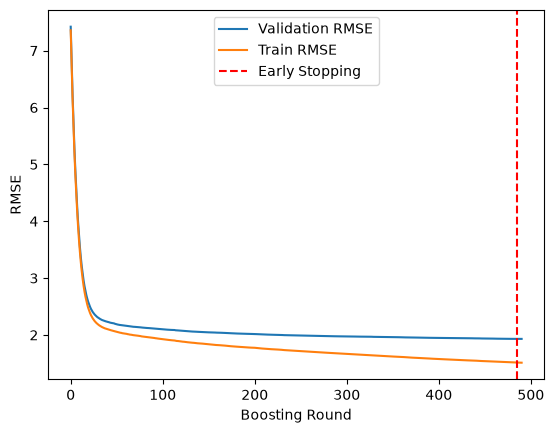

In [16]:
results = model.evals_result()

plt.plot(results['validation_1']['rmse'], label='Validation RMSE')
plt.plot(results['validation_0']['rmse'], label='Train RMSE')
plt.axvline(model.best_iteration, color='red', linestyle='--', label='Early Stopping')
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.legend()
plt.show()


In [17]:
# Renitialize/freeze the model without callback but using best boosting rounds
import xgboost as xgb
model = xgb.XGBRegressor(
    objective='reg:squarederror', # training / gradient computation
    n_estimators=boosting_rounds,
    learning_rate=0.1,
    eval_metric="rmse", #  reports score / early stopping
    n_jobs=-1
)

# model.fit(X_train, y_train) # Will use RSE as loss function

# model.fit(
#     X_train, 
#     y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=True
# )

model.fit(X_train, y_train, verbose=True)

,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'
,feature_types,None


In [18]:
# from sklearn.ensemble import RandomForestRegressor
# xgb = model
# rf = RandomForestRegressor()

In [19]:
# XGBRegressor?
# help(XGBRegressor)

In [20]:
# import inspect
# inspect.signature(xgb.fit)
# XGBRegressor?
# xgb.XGBRegressor.fit?

In [21]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Learning Curve looks at the advantage or disadvantge to have more training data
# #https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html#sphx-glr-auto-examples-model-selection-plot-learning-curve-py

# """
# Learning curve interpretation----------
# Large gap → overfitting (high training score, low test score)
# Both low → underfitting (high bias)
# Close and high → good model, well-generalized
# """

# from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharey=True)

# common_params = {
#     "X": X,
#     "y": y,
#     "train_sizes": np.linspace(0.1, 1.0, 5),
#     "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=42),
#     "score_type": "both",
#     "n_jobs": -1,
#     "line_kw": {"marker": "o"},
#     "std_display_style": "fill_between",
#     "scoring":"r2"
# }

# for ax_idx, estimator in enumerate([xgb, rf]):
#     LearningCurveDisplay.from_estimator(estimator, **common_params, ax=ax[ax_idx])
#     handles, label = ax[ax_idx].get_legend_handles_labels()
#     ax[ax_idx].legend(handles[:2], ["Training Score", "Test Score"])
#     ax[ax_idx].set_title(f"Learning Curve for {estimator.__class__.__name__}")

[learning_curve] Training set sizes: [ 2454  4908  7362  9816 12270 14724 17178 19632 22086 24540]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   26.5s finished


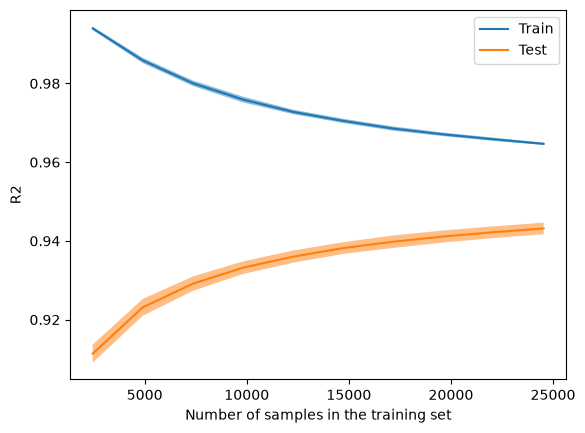

In [22]:
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

common_params = {
    "X": X,
    "y": y,
    "train_sizes": np.linspace(0.1, 1.0, 10),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=42),
    "n_jobs": -1,
    # "scoring":"neg_root_mean_squared_error",
    "scoring":"r2",
    # "random_state": 42,
    "verbose": True
}

# common_params = {
#     "X": X,
#     "y": y,
#     "train_sizes": np.linspace(0.1, 1.0, 5),
#     "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=42),
#     "score_type": "both",
#     "n_jobs": -1,
#     "line_kw": {"marker": "o"},
#     "std_display_style": "fill_between",
#     "scoring":"r2"
# }

fig, ax = plt.subplots()
LearningCurveDisplay.from_estimator(model, **common_params, ax=ax)
plt.show()

In [23]:
# # Initialize model
# import xgboost as xgb
# from xgboost import XGBRegressor

# model = xgb.XGBRegressor(
#     n_estimators=200,
#     learning_rate=0.1,
#     eval_metric="rmse",
#     n_jobs=-1
# )

train_sizes, train_scores, valid_scores = learning_curve(model, **common_params)

# train_sizes, train_scores, valid_scores = learning_curve(model, X, y, 
#                                                          train_sizes=np.linspace(0.1, 1.0, 5),
#                                                          cv=5,
#                                                         scoring="r2", # "neg_mean_squared_error",
#                                                         random_state=42)  # regression metric

[learning_curve] Training set sizes: [ 2454  4908  7362  9816 12270 14724 17178 19632 22086 24540]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   25.8s finished


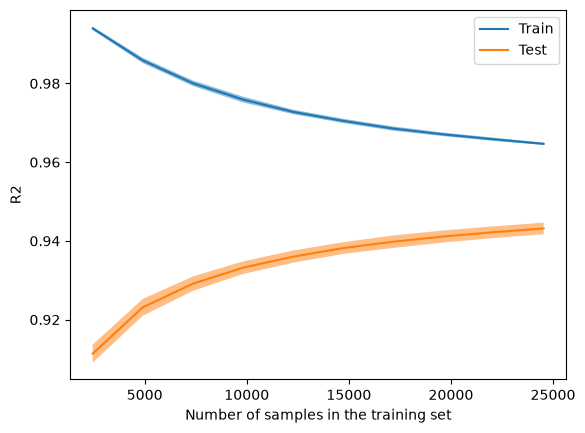

In [24]:
# Directly feed the output of learning curve to LearningCurveDisplay if from_estimator is not used
display = LearningCurveDisplay(train_sizes=train_sizes,
    train_scores=train_scores, test_scores=valid_scores, score_name="R2")
display.plot()
plt.show()

In [25]:
# train_sizes, train_scores, valid_scores = train_sizes, train_scores*-1, valid_scores*-1
train_sizes, train_scores, valid_scores = train_sizes, train_scores, valid_scores
# train_sizes
# train_scores

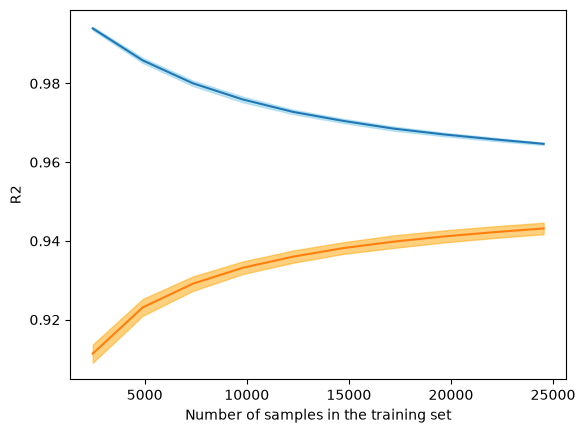

In [26]:
# Or Plot manually
fig, ax = plt.subplots()
plt.plot(train_sizes, np.mean(train_scores, axis=1))
plt.fill_between(train_sizes,
                 np.mean(train_scores, axis=1) + np.std(train_scores, axis=1),
                 np.mean(train_scores, axis=1) - np.std(train_scores, axis=1), 
                 color='skyblue', alpha=0.5)

plt.plot(train_sizes, np.mean(valid_scores, axis=1))
plt.fill_between(train_sizes,
                 np.mean(valid_scores, axis=1) + np.std(valid_scores, axis=1),
                 np.mean(valid_scores, axis=1) - np.std(valid_scores, axis=1), 
                 color='orange', alpha=0.5)
ax.set_xlabel("Number of samples in the training set")
ax.set_ylabel("R2")
plt.show()

In [27]:
# print(np.linspace(0.1, 1.0, 5))

In [28]:
# # https://scikit-learn.org/stable/modules/learning_curve.html
# from sklearn.model_selection import LearningCurveDisplay
# LearningCurveDisplay.from_estimator(model, X, y, train_sizes=np.linspace(0.1, 1.0, 5), cv=5)
# plt.show()

In [29]:
# 9) Make predictions
y_pred = model.predict(X_test)

In [30]:
# 8) Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")

Mean Squared Error: 3.727
R² Score: 0.944


In [31]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model, X, y,
    scoring='neg_root_mean_squared_error',  # RMSE
    cv=kfold
)

print("Cross-Validation RMSE scores:", -cv_scores)
print("Mean RMSE:", -cv_scores.mean()) # Mean score refelcts an overall performance of the model.
print("Std RMSE:", cv_scores.std())

Cross-Validation RMSE scores: [1.93585076 1.91282283 1.91429987 1.91346726 1.97692328]
Mean RMSE: 1.9306727993094277
Std RMSE: 0.0246926837253072


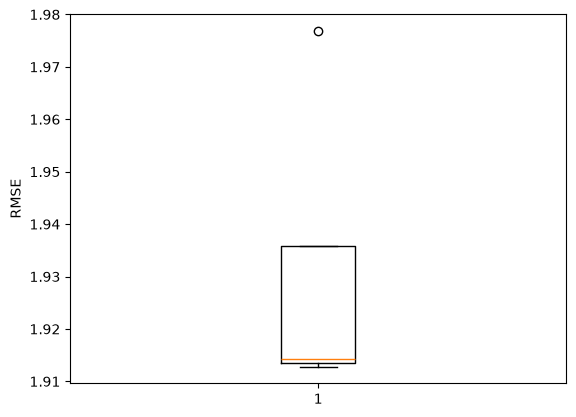

In [32]:
fig, ax = plt.subplots()
plt.boxplot(-cv_scores)
ax.set_ylabel("RMSE")
plt.show()

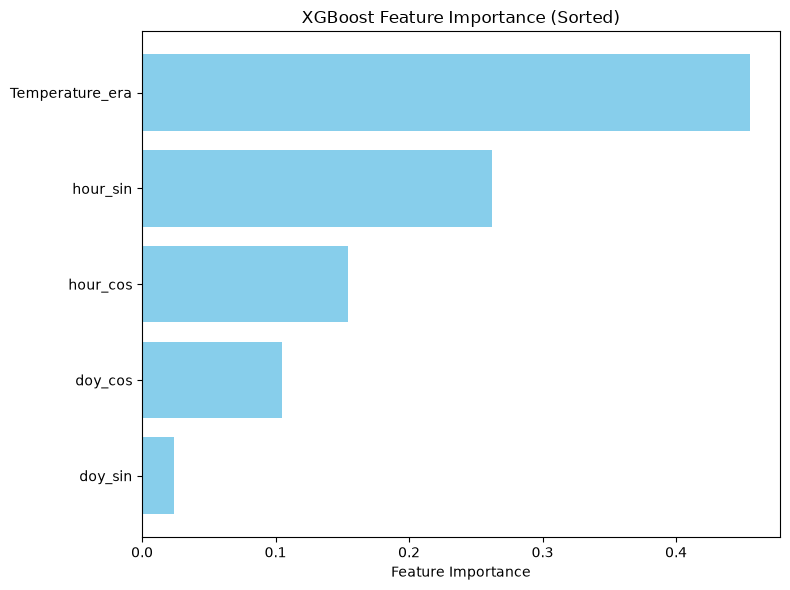

In [33]:
# Get feature importances
importances = model.feature_importances_

# Sort indices in descending order
sorted_idx = np.argsort(importances)[::-1]

# Plot horizontal bar chart
plt.figure(figsize=(8, 6))
plt.barh(range(len(importances)), importances[sorted_idx], color='skyblue')
plt.yticks(range(len(importances)), X.columns[sorted_idx])
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance (Sorted)")
plt.tight_layout()
plt.show()

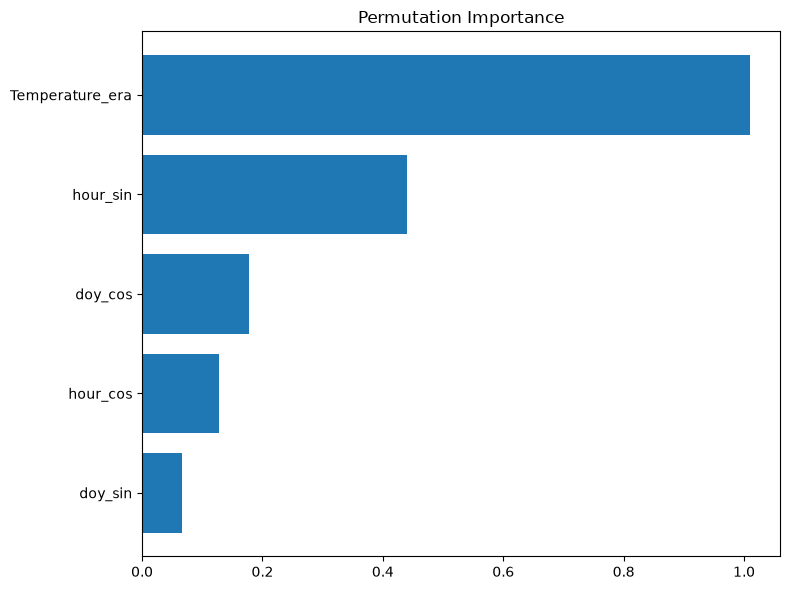

In [34]:
# Permutation Importance (more reliable)
perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42)

sorted_idx = perm.importances_mean.argsort()
plt.figure(figsize=(8, 6))
plt.barh(X.columns[sorted_idx], perm.importances_mean[sorted_idx])
plt.title("Permutation Importance")
plt.tight_layout()
plt.show()

In [35]:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html#sklearn.model_selection.learning_curve

In [36]:
from sklearn.model_selection import ValidationCurveDisplay

In [37]:
param_range = np.arange(10, 400, 30)
print(param_range)

[ 10  40  70 100 130 160 190 220 250 280 310 340 370]


In [38]:
from xgboost import XGBRegressor
import xgboost as xgb

# clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2)
# https://xgboost.readthedocs.io/en/stable/python/sklearn_estimator.html

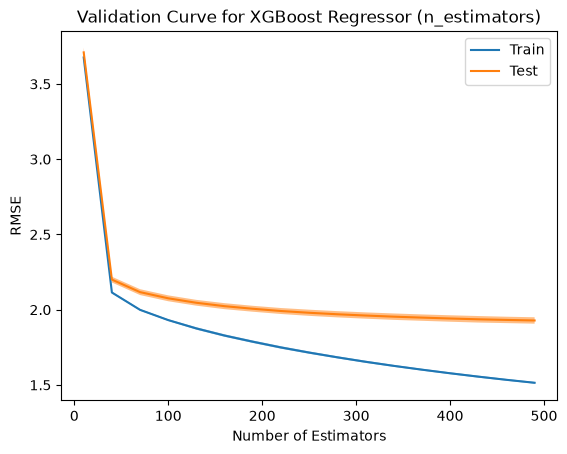

In [41]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import validation_curve, ValidationCurveDisplay
from xgboost import XGBRegressor

# https://scikit-learn.org/stable/modules/learning_curve.html

# # Define model
# xgb = XGBRegressor(
#     learning_rate=0.1,
#     max_depth=3,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=0,
#     eval_metric="rmse"
# )

# Hyperparameter to sweep

param_name = "n_estimators"
param_range = np.arange(10, 500, 30)

# Compute validation curve
train_scores, test_scores = validation_curve(
    model,
    X, y,
    param_name=param_name,
    param_range=param_range,
    scoring="neg_root_mean_squared_error",  # regression metric
    cv=ShuffleSplit(n_splits=50, test_size=0.2, random_state=42),
    n_jobs=-1
)

# Since sklearn returns negative RMSE, convert to positive
train_scores = -train_scores
test_scores = -test_scores

# Plot
display = ValidationCurveDisplay(
    param_name=param_name,
    param_range=param_range,
    train_scores=train_scores,
    test_scores=test_scores,
    score_name="RMSE"
)

display.plot()
plt.title("Validation Curve for XGBoost Regressor (n_estimators)")
plt.xlabel("Number of Estimators")
plt.ylabel("RMSE")
plt.show()

In [42]:
train_scores = -train_scores
test_scores = -test_scores
param_range

array([ 10,  40,  70, 100, 130, 160, 190, 220, 250, 280, 310, 340, 370,
       400, 430, 460, 490])

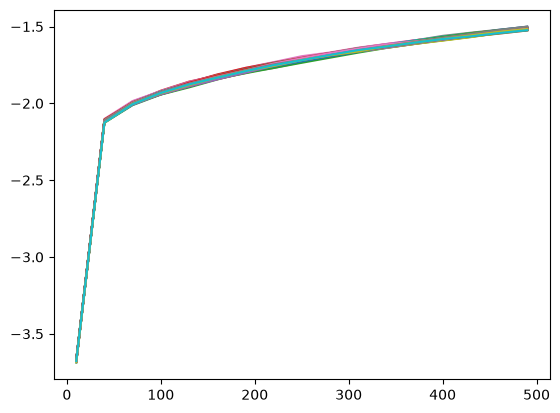

In [43]:
fig, ax = plt.subplots()
plt.plot(param_range, train_scores)
plt.show()

In [44]:
len(param_range)

17

In [45]:
np.mean(train_scores, axis=1)

array([-3.67587151, -2.11424902, -1.99898839, -1.93088514, -1.87538578,
       -1.82816733, -1.78737522, -1.74914342, -1.71506809, -1.68363629,
       -1.65406384, -1.62690093, -1.60161141, -1.57770052, -1.55529493,
       -1.53416963, -1.51442007])

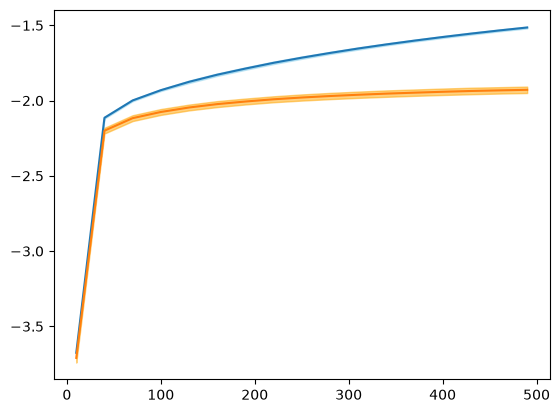

In [46]:
fig, ax = plt.subplots()
plt.plot(param_range, np.mean(train_scores, axis=1))
plt.fill_between(param_range,
                 np.mean(train_scores, axis=1) + np.std(train_scores, axis=1),
                 np.mean(train_scores, axis=1) - np.std(train_scores, axis=1), 
                 color='skyblue', alpha=0.5)

plt.plot(param_range, np.mean(test_scores, axis=1))
plt.fill_between(param_range,
                 np.mean(test_scores, axis=1) + np.std(test_scores, axis=1),
                 np.mean(test_scores, axis=1) - np.std(test_scores, axis=1), 
                 color='orange', alpha=0.5)
plt.show()

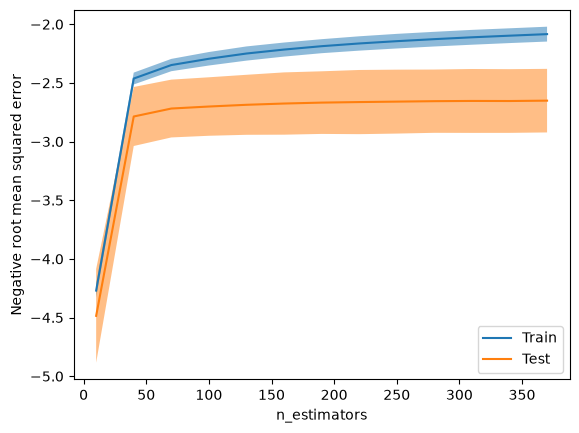

In [47]:
from sklearn.model_selection import ValidationCurveDisplay
# Define model
xgb = XGBRegressor(
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    eval_metric="rmse"
)

# Hyperparameter to sweep
param_name = "n_estimators"
param_range = np.arange(10, 400, 30)

varrr = ValidationCurveDisplay.from_estimator(
    xgb, X, y, param_name=param_name,
    param_range=param_range,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    cv=5
)

plt.show()

In [48]:
varrr.test_scores

array([[-4.25492954, -4.18380793, -4.30074612, -5.26929998, -4.41829375],
       [-2.92909692, -2.31901757, -2.86138348, -2.76889323, -3.05379867],
       [-2.89684247, -2.35044509, -2.79803535, -2.52519693, -3.02259499],
       [-2.89212567, -2.35850452, -2.75419209, -2.47847892, -3.02408495],
       [-2.88240975, -2.35679531, -2.73158308, -2.43671038, -3.02627091],
       [-2.87940399, -2.34700546, -2.71191379, -2.40666147, -3.03497339],
       [-2.88006663, -2.33999585, -2.69779287, -2.39596828, -3.02667553],
       [-2.88718488, -2.33788457, -2.69034486, -2.37354151, -3.02836302],
       [-2.8815129 , -2.34022034, -2.68324064, -2.36777408, -3.02557022],
       [-2.88268069, -2.34098357, -2.68137031, -2.3628713 , -3.01154605],
       [-2.88836262, -2.34254479, -2.67720864, -2.3515523 , -3.00999051],
       [-2.889219  , -2.34546286, -2.67438135, -2.35337034, -3.0103218 ],
       [-2.88872104, -2.34902165, -2.66575189, -2.34675322, -3.00671972]])

In [50]:
import xgboost as xgb
print(xgb.__version__)

import shap
print(shap.__version__)

# xgboost == 2.1.4
# shap == 0.45.1

2.1.4
0.45.1


In [51]:
import xgboost as xgb

# Prepare data
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test)

# https://xgboost.readthedocs.io/en/latest/python/python_api.html
# https://xgboost.readthedocs.io/en/latest/python/python_api.html

# model = xgb.XGBRegressor(
#     objective='reg:squarederror', # training / gradient computation
#     n_estimators=boosting_rounds,
#     learning_rate=0.1,
#     eval_metric="rmse", #  reports score / early stopping
#     n_jobs=-1
# )

In [52]:
dtrain, dtest 

(<xgboost.core.DMatrix at 0x1d95d7a9c50>,
 <xgboost.core.DMatrix at 0x1d95dd628d0>)

In [53]:
params = {
    "objective": "reg:squarederror",
    "eta": 0.1,
    "n_jobs":4
}

model_xgb = xgb.train(params, dtrain, num_boost_round=500)

# # Predict
# y_pred = model.predict(X_test)
# y_pred

In [54]:
# pred = model_xgb.predict(dtest, output_margin=True)
explainer = shap.TreeExplainer(model_xgb)
explanation = explainer(dtest)
shap_values = explanation.values

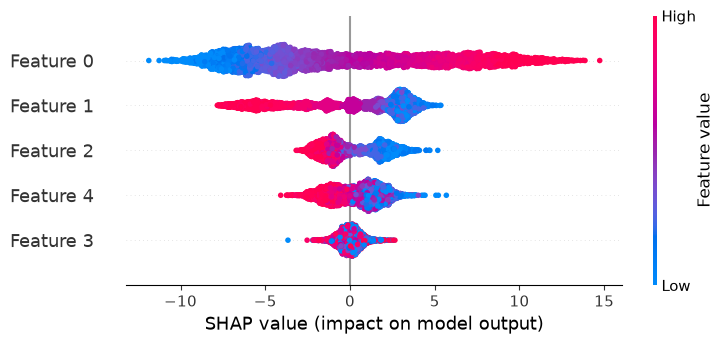

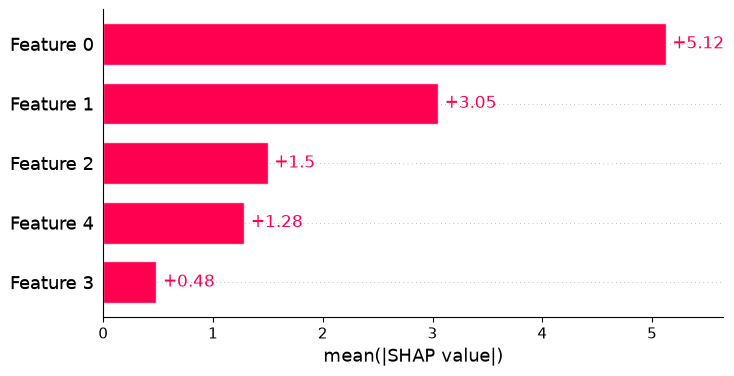

In [55]:
shap.plots.beeswarm(explanation)
shap.plots.bar(explanation)

In [56]:
from xgboost import XGBRegressor
import shap

model_shap = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=3)
model_shap.fit(X_train, y_train)

explainer = shap.TreeExplainer(model_shap)
# shap_values = explainer.shap_values(X_test)
shap_values = explainer(X_test)


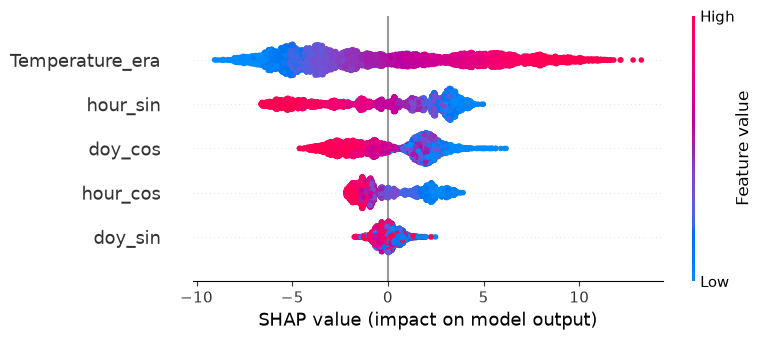

In [57]:
shap.summary_plot(shap_values, X_test)

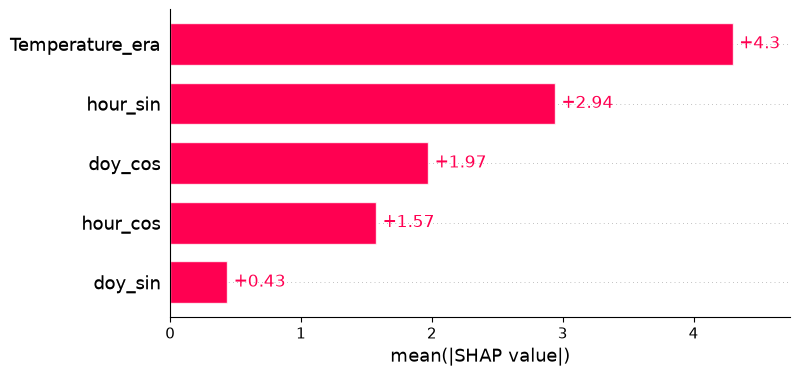

In [58]:
shap.plots.bar(shap_values)

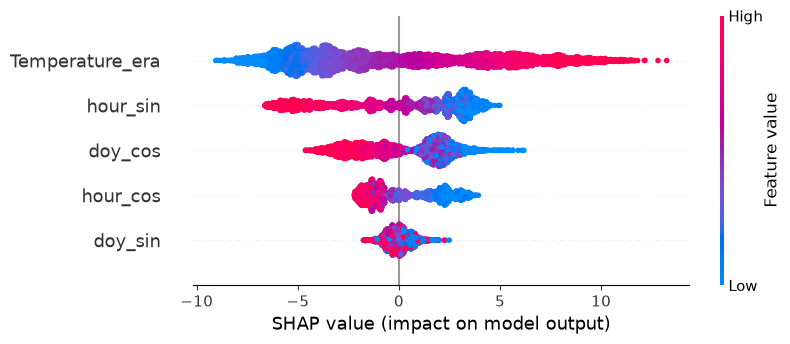

In [59]:
shap.plots.beeswarm(shap_values)

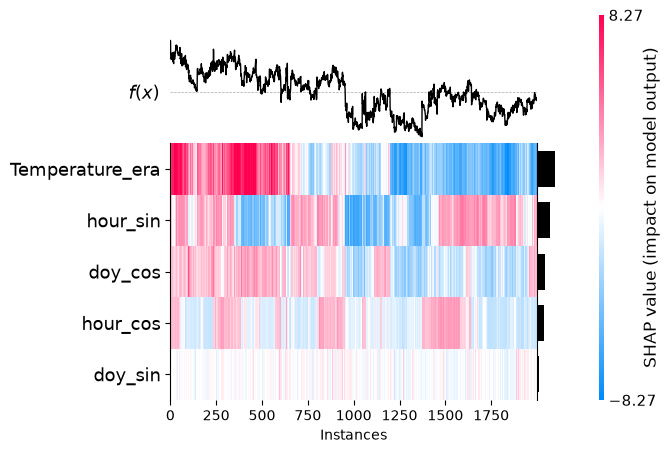

<Axes: xlabel='Instances'>

In [60]:
shap.plots.heatmap(shap_values[:2000])

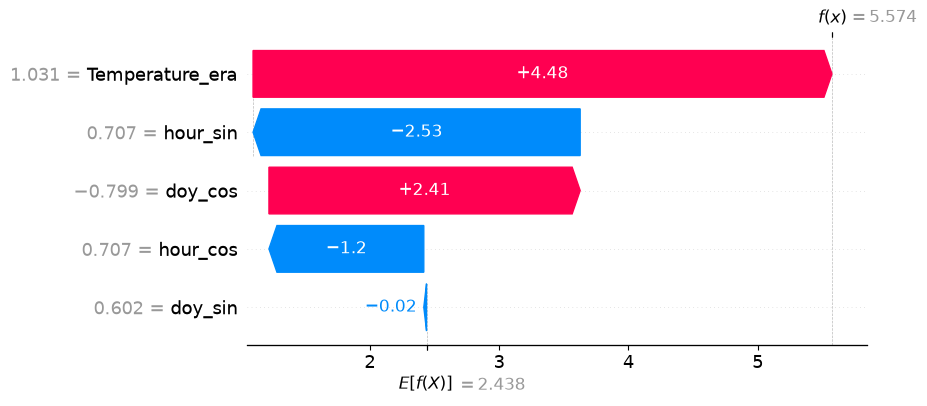

In [61]:
shap.plots.waterfall(shap_values[0], max_display=14) # f(x) is the model output; E[f(X)] is the expected value

In [62]:
X_test

,Temperature_era,hour_sin,hour_cos,doy_sin,doy_cos
21495,1.031473,0.707107,0.707107,0.601624,-0.798779
19308,-24.760519,0.000000,1.000000,0.801361,0.598181
12054,-15.858481,-0.965926,-0.258819,0.255353,0.966848
3000,-14.189337,0.258819,-0.965926,0.051620,0.998667
12724,-16.726843,-0.707107,-0.707107,0.674444,0.738326
...,...,...,...,...,...
29700,-11.595297,0.000000,1.000000,0.871706,-0.490029
6994,-0.361929,-0.707107,0.707107,0.230306,-0.973118
19690,-24.609885,-0.500000,0.866025,0.927542,0.373720
16030,4.614191,0.500000,-0.866025,-0.989932,0.141540


In [63]:
y_pred = model.predict(X_test)
y_pred

array([  5.792269  , -13.083244  ,   0.23801865, ...,  -6.291309  ,
        12.103931  ,  15.009475  ], dtype=float32)

In [64]:
np.mean(y_pred)

2.461796

In [66]:
#%% Halji and Yalbang Met Station Validation

def OOD_Validation(era5_data, station_data, xgb_model):

    # Era5 Data
    yalbang_era5_data = read_data(era5_data)
    variable_name1, variable_name2 = "Date", "Temperature_era"
    yalbang_era5_var = extract_variables(yalbang_era5_data, variable_name1, variable_name2)
    
    yalbang_era5 = add_time_features(yalbang_era5_var)
    
    X_new = yalbang_era5[['Temperature_era', 
                     'hour_sin', 
                     'hour_cos', 
                     'doy_sin', 
                     'doy_cos']]
    
    y_pred_new = xgb_model.predict(X_new)
    yalbang_era5['pred_temp'] = y_pred_new
    
    # Station data
    yalbang_met = read_data(station_data)
    
    # Suppose you already have:
    variable_name1, variable_name2 = "Date", "Temperature_st"
    yalbang_met_var = extract_variables(yalbang_met, variable_name1, variable_name2)
    
    # yalbang_met_var['Temperature_st'] = fahrenheit_to_celsius(yalbang_met_var['Temperature_st'])
    
    yalbang_met_era5 = pd.merge(
        yalbang_met_var,
        yalbang_era5,
        on=['Date'], 
        how='inner'
    )

    return (yalbang_met_era5['Temperature_st'], yalbang_met_era5['pred_temp'])

In [67]:
#%% Yalbang

era5_data_file = "Zhang_ERA5L_hourly_9km_Yalbang.csv"
station_data_file = "Yalbang_Met.csv"

yalbang = OOD_Validation(era5_data_file, station_data_file, model)

era5_data_file_h = "Zhang_ERA5L_hourly_9km_Halji.csv"
station_data_file_h = "10717835_Halji_Met_Temp.csv"

halji = OOD_Validation(era5_data_file_h, station_data_file_h, model)

2022-01-01 00:00:00
2025-06-18 23:00:00
2023-09-08 11:00:00
2024-09-08 16:00:00
2022-01-01 00:00:00
2025-06-18 23:00:00
2024-09-11 16:00:00
2025-03-08 19:00:00


0.9409993859989714 0.1820920567675377 0.9713883910163751 0.943595406201382
1.1698150062945911 -5.187914595874062 0.9502470254657377 0.9029694094064823
1.0051068009209065 -0.45055303404986957 0.9303067863076855 0.8654707166501335


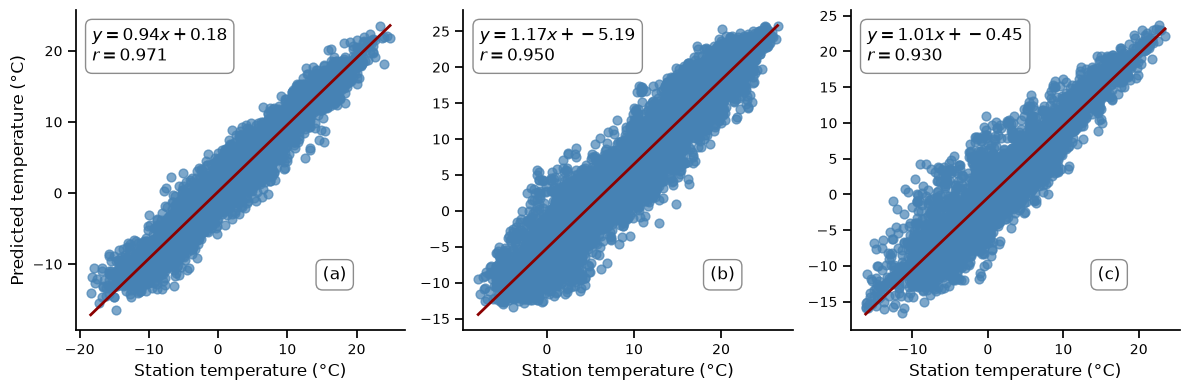

In [68]:
import seaborn as sns
from scipy.stats import linregress

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

datasets = [(y_test, y_pred), yalbang, halji]
fig_labels =  ['(a)', '(b)', '(c)']

for i, (ax, (x_data, y_data)) in enumerate(zip(axs, datasets)):

    sns.regplot(
        x=x_data, y=y_data,
        scatter_kws={'s': 40, 'color': 'steelblue', 'alpha': 0.7},
        line_kws={'color': 'darkred', 'linewidth': 2},
        ax=ax
    )
    
    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    r_squared = r_value**2
    
    print(slope, intercept, r_value, r_squared)

    # Spines
    ax.spines['bottom'].set_linewidth(1.25)
    ax.spines['bottom'].set_color('black')

    ax.spines['left'].set_linewidth(1.25)
    ax.spines['left'].set_color('black')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(labelbottom=True, labelleft=True)

    # Ticks
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    # Customize major tick parameters (length, width)
    ax.tick_params(axis='x', which='major', direction='out', length=6, width=1.25)
    ax.tick_params(axis='y', which='major', direction='out', length=6, width=1.25)

    ax.grid(False)

    ax.text(
        0.05, 0.95,
        # f"$y = {slope:.2f}x + {intercept:.2f}$\n$R^2 = {r_squared:.3f}$",
        f"$y = {slope:.2f}x + {intercept:.2f}$\n$r = {r_value:.3f}$",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.4", edgecolor='gray', facecolor='white', alpha=0.9)
    )
    
    ax.text(
        0.75, 0.2, fig_labels[i],
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.4", edgecolor='gray', facecolor='white', alpha=0.9)
    )
    
axs[0].set_xlabel('Station temperature (°C)', fontsize=12)
axs[1].set_xlabel('Station temperature (°C)', fontsize=12)
axs[2].set_xlabel('Station temperature (°C)', fontsize=12)

axs[0].set_ylabel('Predicted temperature (°C)', fontsize=12)
axs[1].set_ylabel('')
axs[2].set_ylabel('')

plt.tight_layout()
plt.show()

# fig.savefig('Model_evaluation.jpg', dpi=300)
# fig.savefig('Til-ml-model.jpg', dpi=300)

In [73]:
import os
direct = r"D:\ML_Learn\ML_Temp_Reconstruction\ERA5-TS"
files = os.listdir(direct)

In [74]:

def read_and_concat_era5l_csvs(file_list, directory_path):
    """
    Reads multiple ERA5L CSV files with columns ['date', 'temperature']
    and concatenates them into a single DataFrame.
    
    Parameters:
    - file_list: List of filenames to read.
    - directory_path: Directory where files are located (default is current directory).
    
    Returns:
    - Combined pandas DataFrame with all rows concatenated.
    """
    dfs = []
    for file in file_list:
        file_path = os.path.join(directory_path, file)
        df = pd.read_csv(file_path, usecols=['date', 'temperature'])
        dfs.append(df)
    
    combined_df = pd.concat(dfs, ignore_index=True)
    combined_df = combined_df.reset_index()
    combined_df.rename(columns={'date': 'Date', 'temperature': 'Temperature_era'}, inplace=True)
    
    return combined_df


combined_data = read_and_concat_era5l_csvs(files, directory_path=direct)

In [75]:
combined_data

,index,Date,Temperature_era
0,0,1950-01-01 01:00:00,-24.929907
1,1,1950-01-01 02:00:00,-24.097250
2,2,1950-01-01 03:00:00,-22.111288
3,3,1950-01-01 04:00:00,-19.593680
4,4,1950-01-01 05:00:00,-15.875021
...,...,...,...
661554,661554,2025-06-20 19:00:00,4.085718
661555,661555,2025-06-20 20:00:00,3.638284
661556,661556,2025-06-20 21:00:00,3.003885
661557,661557,2025-06-20 22:00:00,2.502969


In [76]:
era5_ts = add_time_features(combined_data)
era5_ts.head()

,index,Date,Temperature_era,hour_sin,hour_cos,doy_sin,doy_cos
0,0,1950-01-01 01:00:00,-24.929907,0.258819,0.965926,0.017213,0.999852
1,1,1950-01-01 02:00:00,-24.097250,0.500000,0.866025,0.017213,0.999852
2,2,1950-01-01 03:00:00,-22.111288,0.707107,0.707107,0.017213,0.999852
3,3,1950-01-01 04:00:00,-19.593680,0.866025,0.500000,0.017213,0.999852
4,4,1950-01-01 05:00:00,-15.875021,0.965926,0.258819,0.017213,0.999852


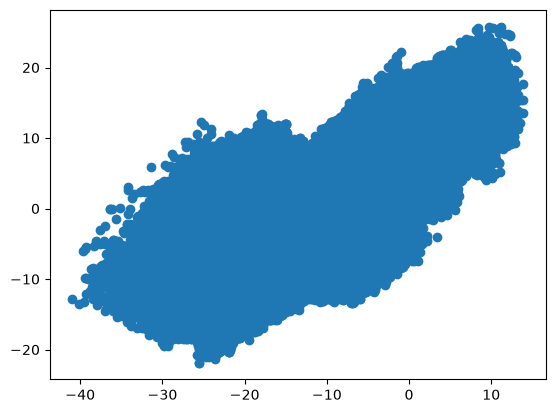

In [77]:
#%% Model prediction on Til dataset
era5_ts_sub = era5_ts[['Temperature_era', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']]
era5_ts_pred_temp = model.predict(era5_ts_sub)

era5_ts['pred_temp'] = era5_ts_pred_temp

fig, ax = plt.subplots()
plt.scatter(era5_ts['Temperature_era'], era5_ts['pred_temp'])
plt.show()

era5_ts.to_csv('era5_ts_pred.csv')

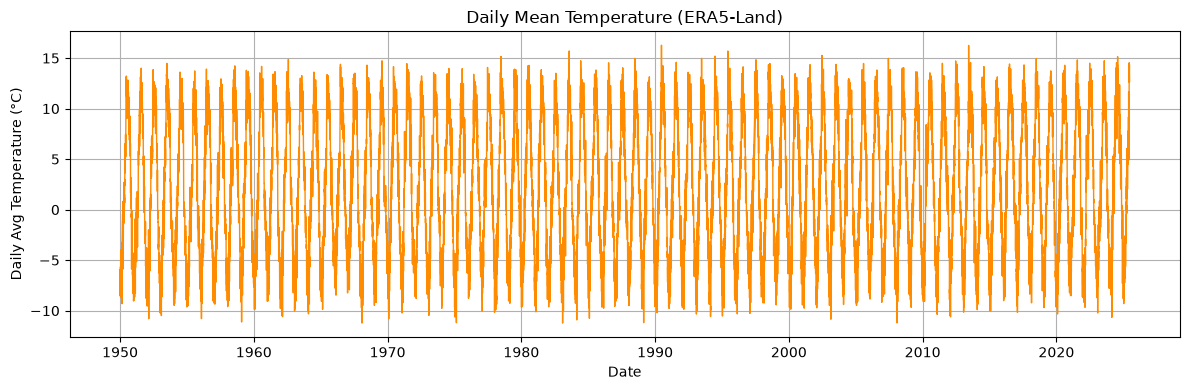

In [78]:
#%% Daily Mean

era5_ts['Date'] = pd.to_datetime(era5_ts['Date'])
era5_ts = era5_ts.set_index('Date')
era5_ts_daily_mean = era5_ts.resample('D').mean()

plt.figure(figsize=(12, 4))
plt.plot(era5_ts_daily_mean.index, 
         era5_ts_daily_mean['pred_temp'], 
         color='darkorange',
         linewidth=1)

plt.xlabel('Date')
plt.ylabel('Daily Avg Temperature (°C)')
plt.title('Daily Mean Temperature (ERA5-Land)')
plt.grid(True)
plt.tight_layout()
plt.show()

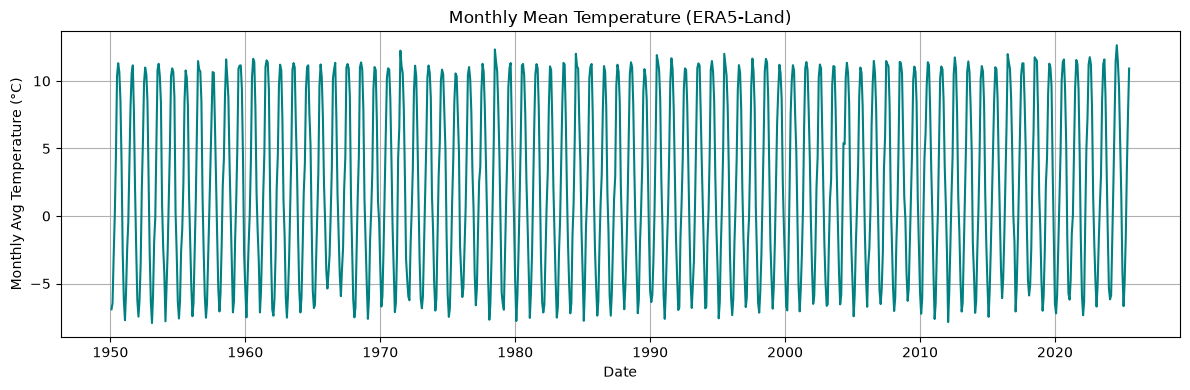

In [79]:
#%% Monthly mean

era5_ts_monthly_mean = era5_ts.resample('ME').mean()

plt.figure(figsize=(12, 4))
plt.plot(era5_ts_monthly_mean.index,
         era5_ts_monthly_mean['pred_temp'],
         color='teal', 
         linewidth=1.5)

plt.xlabel('Date')
plt.ylabel('Monthly Avg Temperature (°C)')
plt.title('Monthly Mean Temperature (ERA5-Land)')
plt.grid(True)
plt.tight_layout()
plt.show()

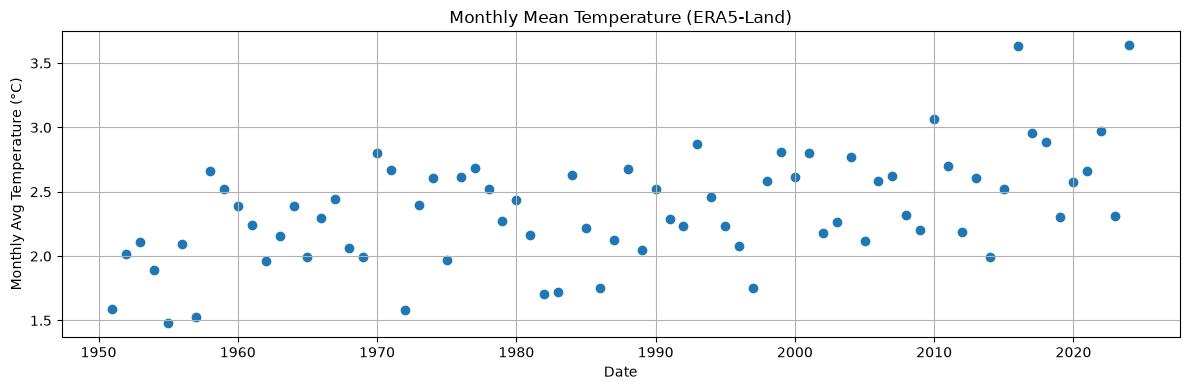

In [80]:
#%% Yearly Mean

era5_ts_yearly_mean = era5_ts.resample('YS').mean()
# era5_ts_yearly_mean = era5_ts_yearly_mean[era5_ts_yearly_mean.index.year < 2025]
era5_ts_yearly_mean = era5_ts_yearly_mean[(era5_ts_yearly_mean.index.year < 2025) & 
                                          (era5_ts_yearly_mean.index.year >= 1951)]

plt.figure(figsize=(12, 4))
plt.scatter(era5_ts_yearly_mean.index,
         era5_ts_yearly_mean['pred_temp'])

plt.xlabel('Date')
plt.ylabel('Monthly Avg Temperature (°C)')
plt.title('Monthly Mean Temperature (ERA5-Land)')
plt.grid(True)
plt.tight_layout()
plt.show()

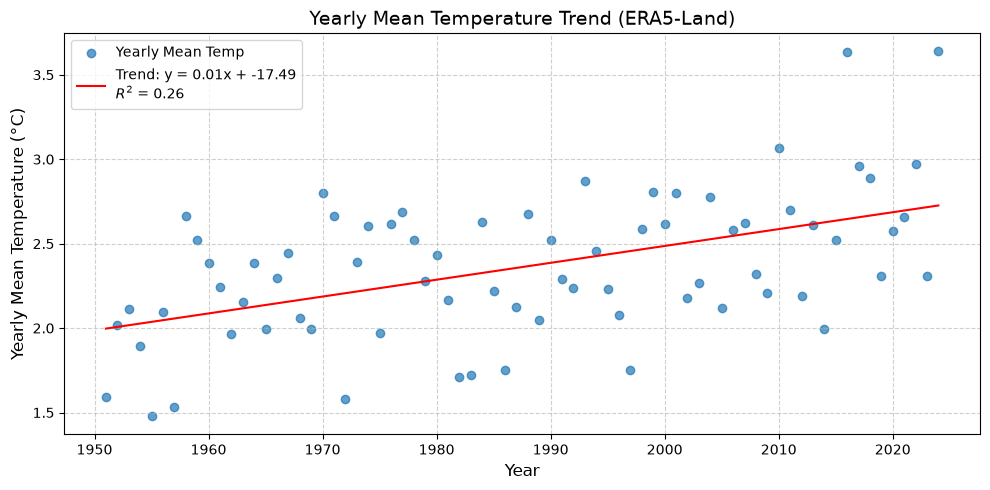

In [81]:

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Prepare data for trend line
x = era5_ts_yearly_mean.index.year.values.reshape(-1, 1)
y = era5_ts_yearly_mean['pred_temp'].values

# Linear regression
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

# Trend line equation
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(x, y)

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='tab:blue', label='Yearly Mean Temp', alpha=0.7)
plt.plot(x, y_pred, color='red', label=f'Trend: y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r_squared:.2f}')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Yearly Mean Temperature (°C)', fontsize=12)
plt.title('Yearly Mean Temperature Trend (ERA5-Land)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()

plt.show()

In [82]:
# Extract temperature values for 1950 and 2024
temp_1950 = era5_ts_yearly_mean.loc['1951-01-01', 'pred_temp']
temp_2024 = era5_ts_yearly_mean.loc['2024-01-01', 'pred_temp']

# Calculate temperature increase
temp_increase = temp_2024 - temp_1950

print(f"Temperature increased by {temp_increase:.2f} °C from 1950 to 2024.")

Temperature increased by 2.05 °C from 1950 to 2024.


In [83]:

from sklearn.linear_model import LinearRegression

# Prepare x (years) and y (temperature)
x = era5_ts_yearly_mean.index.year.values.reshape(-1, 1)
y = era5_ts_yearly_mean['pred_temp'].values

# Fit linear regression
model = LinearRegression()
model.fit(x, y)

# Predict temperature for 1950 and 2024 using the trend line
temp_1950_trend = model.predict([[1951]])[0]
temp_2024_trend = model.predict([[2024]])[0]

# Calculate estimated increase
temp_change_trend = temp_2024_trend - temp_1950_trend

print(f"Estimated temperature increase from trend line (1950–2024): {temp_change_trend:.2f} °C")

Estimated temperature increase from trend line (1950–2024): 0.73 °C


In [84]:

slope = model.coef_[0]
intercept = model.intercept_
print(f"Trend line equation: y = {slope:.4f}x + {intercept:.2f}")


Trend line equation: y = 0.0100x + -17.49


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     24.92
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.02e-06
Time:                        19:33:44   Log-Likelihood:                -29.937
No. Observations:                  74   AIC:                             63.87
Df Residuals:                      72   BIC:                             68.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.4887      3.977     -4.398      0.0

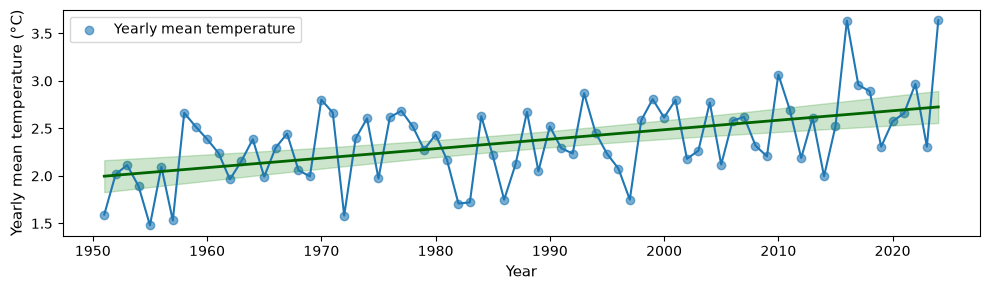

Estimated trend-based temperature change from 1950 to 2024: 0.73 °C


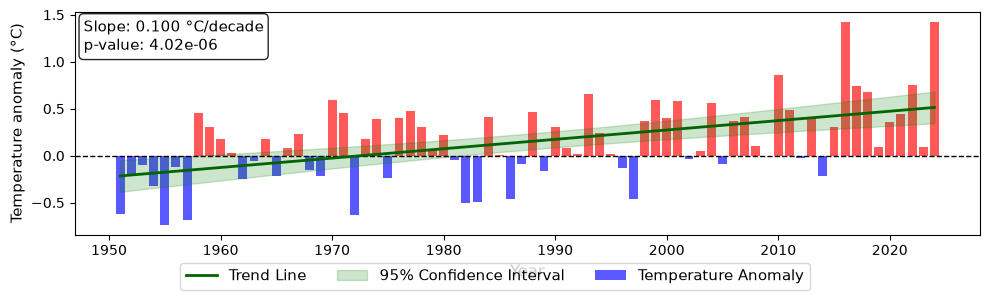

In [85]:

import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd


# Prepare the data
x = era5_ts_yearly_mean.index.year.values
y = era5_ts_yearly_mean['pred_temp'].values

# Add constant (intercept) term for statsmodels
X = sm.add_constant(x)

# Fit OLS model
model = sm.OLS(y, X).fit()
print(model.summary())
p_value = model.pvalues[1]  # index 1 corresponds to x1 (slope)
print(f"P-value for the linear trend: {p_value:.4e}")

predictions = model.get_prediction(X)
prediction_summary = predictions.summary_frame(alpha=0.05)  # 95% CI

y_pred = prediction_summary['mean']
ci_lower = prediction_summary['mean_ci_lower']
ci_upper = prediction_summary['mean_ci_upper']

plt.figure(figsize=(10, 3))

plt.plot(x, y)
plt.scatter(x, y, color='tab:blue', alpha=0.6, label='Yearly mean temperature')
plt.plot(x, y_pred, color='darkgreen', linewidth=2)
plt.fill_between(x, ci_lower, ci_upper, color='green', alpha=0.2)

plt.xlabel('Year', fontsize=11)
plt.ylabel('Yearly mean temperature (°C)', fontsize=11)

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Print the temperature change estimate from trend
temp_1950 = model.predict([1, 1951])[0]
temp_2024 = model.predict([1, 2024])[0]
print(f"Estimated trend-based temperature change from 1950 to 2024: {temp_2024 - temp_1950:.2f} °C")


import matplotlib.pyplot as plt
import statsmodels.api as sm


# Step 1: Compute baseline mean for 1950–1980
baseline_period = era5_ts_yearly_mean[
    (era5_ts_yearly_mean.index.year >= 1951) &
    (era5_ts_yearly_mean.index.year <= 1980)
]

baseline_mean = baseline_period['pred_temp'].mean()

# Step 2: Calculate anomaly
era5_ts_yearly_mean['temp_anomaly'] = era5_ts_yearly_mean['pred_temp'] - baseline_mean

# Step 3: Prepare data for trend fitting
anomaly_series = era5_ts_yearly_mean['temp_anomaly'].dropna()
years = anomaly_series.index.year.values
anomalies = anomaly_series.values

# Step 4: Fit linear model with statsmodels
X = sm.add_constant(years)
model = sm.OLS(anomalies, X).fit()

# Prediction + CI
pred = model.get_prediction(X)
pred_summary = pred.summary_frame(alpha=0.05)

y_fit = pred_summary['mean']
ci_lower = pred_summary['mean_ci_lower']
ci_upper = pred_summary['mean_ci_upper']
slope = model.params[1]
p_value = model.pvalues[1]

# Step 5: Plot
fig, ax = plt.subplots(figsize=(10, 3))
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# Plot bar anomalies
bars = ax.bar(
    years, anomalies,
    color=['red' if val > 0 else 'blue' for val in anomalies],
    label='Temperature Anomaly', alpha=0.65,
)

# Trend line and CI
trend_line, = ax.plot(years, y_fit, color='darkgreen', linewidth=2, label='Trend Line')
ci_patch = ax.fill_between(years, ci_lower, ci_upper, color='green', alpha=0.2, label='95% Confidence Interval')

# Annotation
ax.text(0.01, 0.97,
        f"Slope: {slope * 10:.3f} °C/decade\np-value: {p_value:.3g}",
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
        fontsize=11)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature anomaly (°C)', fontsize=11)

handles, labels = ax.get_legend_handles_labels()

# Add combined legend at bottom center
fig.legend(handles, labels,
           loc='lower center',
           ncol=3,
           fontsize=11,
           frameon=True,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

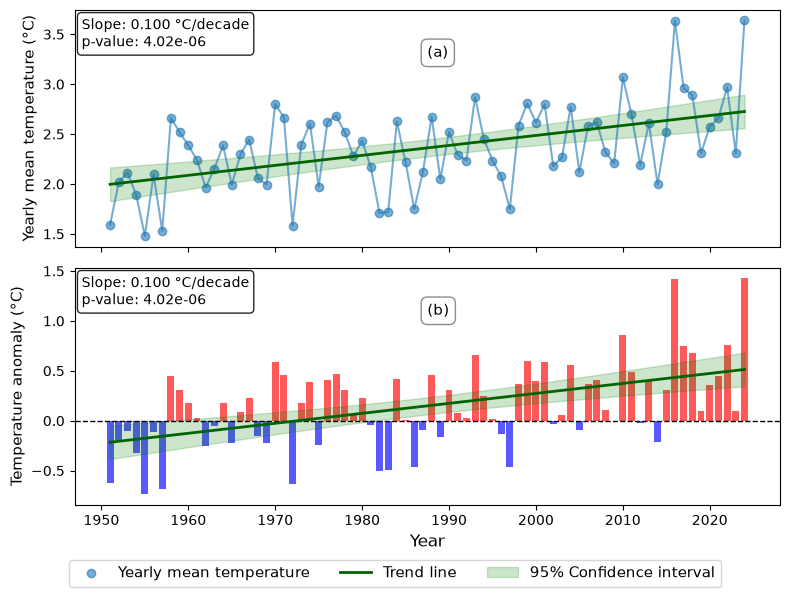

Estimated trend-based temperature change from 1950 to 2024: 0.73 °C


In [86]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

x = era5_ts_yearly_mean.index.year.values
y = era5_ts_yearly_mean['pred_temp'].values
X = sm.add_constant(x)
model_temp = sm.OLS(y, X).fit()
pred_temp = model_temp.get_prediction(X).summary_frame(alpha=0.05)

y_pred_temp = pred_temp['mean']
ci_lower_temp = pred_temp['mean_ci_lower']
ci_upper_temp = pred_temp['mean_ci_upper']
p_value_temp = model_temp.pvalues[1]
temp_1950 = model_temp.predict([1, 1951])[0]
temp_2024 = model_temp.predict([1, 2024])[0]
temp_change = temp_2024 - temp_1950

baseline_period = era5_ts_yearly_mean[
    (era5_ts_yearly_mean.index.year >= 1951) & 
    (era5_ts_yearly_mean.index.year <= 1980)
]

baseline_mean = baseline_period['pred_temp'].mean()
era5_ts_yearly_mean['temp_anomaly'] = era5_ts_yearly_mean['pred_temp'] - baseline_mean

anomaly_series = era5_ts_yearly_mean['temp_anomaly'].dropna()
years = anomaly_series.index.year.values
anomalies = anomaly_series.values
X_anom = sm.add_constant(years)
model_anom = sm.OLS(anomalies, X_anom).fit()
pred_anom = model_anom.get_prediction(X_anom).summary_frame(alpha=0.05)

y_fit_anom = pred_anom['mean']
ci_lower_anom = pred_anom['mean_ci_lower']
ci_upper_anom = pred_anom['mean_ci_upper']
slope_anom = model_anom.params[1]
p_value_anom = model_anom.pvalues[1]

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].plot(x, y, color='tab:blue', alpha=0.6)
scatter = axs[0].scatter(x, y, color='tab:blue', alpha=0.6, label='Yearly mean temperature')
line1, = axs[0].plot(x, y_pred_temp, color='darkgreen', linewidth=2)
ci1 = axs[0].fill_between(x, ci_lower_temp, ci_upper_temp, color='green', alpha=0.2)

axs[0].set_ylabel('Yearly mean temperature (°C)', fontsize=11)
axs[0].text(0.01, 0.97,
            f"Slope: {model_temp.params[1]*10:.3f} °C/decade\np-value: {p_value_temp:.3g}",
            transform=axs[0].transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
            fontsize=10)

axs[1].axhline(0, color='black', linestyle='--', linewidth=1)

bars = axs[1].bar(
    years, anomalies,
    color=['red' if val > 0 else 'blue' for val in anomalies], alpha=0.65,
)

line2, = axs[1].plot(years, y_fit_anom, color='darkgreen', linewidth=2, label='Trend line')
ci2 = axs[1].fill_between(years, ci_lower_anom, ci_upper_anom, color='green', alpha=0.2, label='95% Confidence interval')

axs[1].set_xlabel('Year', fontsize=12)
axs[1].set_ylabel('Temperature anomaly (°C)', fontsize=11)
axs[1].text(0.01, 0.97,
            f"Slope: {slope_anom * 10:.3f} °C/decade\np-value: {p_value_anom:.3g}",
            transform=axs[1].transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
            fontsize=10)

fig_labels = ['(a)', '(b)']

for i, ax in enumerate(axs):
    
    ax.text(
        0.5, 0.85, fig_labels[i],
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.4", edgecolor='gray', facecolor='white', alpha=0.9)
    )

handles_1, labels_1 = axs[0].get_legend_handles_labels()
handles_2, labels_2 = axs[1].get_legend_handles_labels()

all_handles = handles_1 + handles_2
all_labels = labels_1 + labels_2

# Remove duplicates (optional)
from collections import OrderedDict
unique = OrderedDict(zip(all_labels, all_handles))

# Add combined legend at bottom
fig.legend(unique.values(), unique.keys(),
           loc='lower center',
           ncol=3,
           fontsize=11,
           frameon=True,
           bbox_to_anchor=(0.5, 0))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

# fig.savefig('Til-years.jpg', dpi=300)
# Print warming estimate
print(f"Estimated trend-based temperature change from 1950 to 2024: {temp_change:.2f} °C")


In [87]:

import pandas as pd

# Assuming anomaly_series has datetime or year as index and temperature anomaly as values
# Step 1: Make sure index is a datetime or integer year
anomaly_series = era5_ts_yearly_mean['temp_anomaly'].dropna()
anomaly_series.index = pd.to_datetime(anomaly_series.index, format='%Y').year  # in case index is string

# Step 2: Convert to a DataFrame with decade column
df = anomaly_series.to_frame(name='anomaly')
df['decade'] = (df.index // 10) * 10  # e.g., 1951 → 1950s

# Step 3: Add boolean column for positive anomalies
df['positive_anomaly'] = df['anomaly'] > 0

# Step 4: Count number and frequency of positive anomalies per decade
positive_counts = df.groupby('decade')['positive_anomaly'].sum()
total_counts = df.groupby('decade')['positive_anomaly'].count()
frequency = (positive_counts / total_counts) * 100  # percentage

# Step 5: Combine and print
result = pd.DataFrame({
    'positive_years': positive_counts,
    'total_years': total_counts,
    'frequency_%': frequency.round(1)
})

print(result)

        positive_years  total_years  frequency_%
decade                                          
1950                 2            9         22.2
1960                 5           10         50.0
1970                 8           10         80.0
1980                 4           10         40.0
1990                 8           10         80.0
2000                 7           10         70.0
2010                 8           10         80.0
2020                 5            5        100.0


In [88]:
import pandas as pd

# Assuming 'anomaly_series' is a Series with years as index and anomalies as values
anomaly_series = era5_ts_yearly_mean['temp_anomaly'].dropna()
anomaly_series.index = pd.to_datetime(anomaly_series.index, format='%Y').year

# Step 1: Create a DataFrame
df = anomaly_series.to_frame(name='anomaly')
df['decade'] = (df.index // 10) * 10
df['positive'] = df['anomaly'] > 0

# Step 2: Group by decade and calculate:
# - frequency of positive years
# - average anomaly (all years)
# - average anomaly (positive years only)
grouped = df.groupby('decade')

summary = pd.DataFrame({
    'positive_years': grouped['positive'].sum(),
    'total_years': grouped['positive'].count(),
    'frequency_%': grouped['positive'].mean() * 100,
    'mean_anomaly_all': grouped['anomaly'].mean().round(3),
    'mean_anomaly_positive': grouped.apply(lambda g: g[g['positive']]['anomaly'].mean()).round(3)
})

summary

,positive_years,total_years,frequency_%,mean_anomaly_all,mean_anomaly_positive
decade,,,,,
1950,2,9,22.222222,-0.223,0.378
1960,5,10,50.000000,-0.021,0.138
1970,8,10,80.000000,0.199,0.358
1980,4,10,40.000000,-0.065,0.276
1990,8,10,80.000000,0.170,0.287
2000,7,10,70.000000,0.235,0.355
2010,8,10,80.000000,0.475,0.623
2020,5,5,100.000000,0.617,0.617


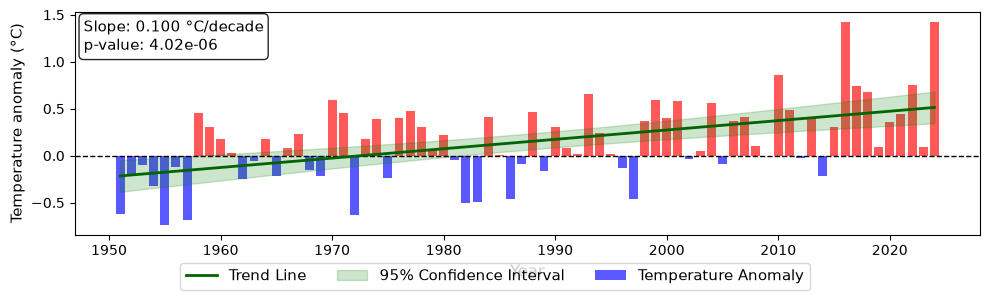

In [89]:
#%% Yearly anomalies

import matplotlib.pyplot as plt
import statsmodels.api as sm


# Step 1: Compute baseline mean for 1950–1980
baseline_period = era5_ts_yearly_mean[
    (era5_ts_yearly_mean.index.year >= 1950) &
    (era5_ts_yearly_mean.index.year <= 1980)
]
baseline_mean = baseline_period['pred_temp'].mean()

# Step 2: Calculate anomaly
era5_ts_yearly_mean['temp_anomaly'] = era5_ts_yearly_mean['pred_temp'] - baseline_mean

# Step 3: Prepare data for trend fitting
anomaly_series = era5_ts_yearly_mean['temp_anomaly'].dropna()
years = anomaly_series.index.year.values
anomalies = anomaly_series.values

# Step 4: Fit linear model with statsmodels
X = sm.add_constant(years)
model = sm.OLS(anomalies, X).fit()

# Prediction + CI
pred = model.get_prediction(X)
pred_summary = pred.summary_frame(alpha=0.05)

y_fit = pred_summary['mean']
ci_lower = pred_summary['mean_ci_lower']
ci_upper = pred_summary['mean_ci_upper']
slope = model.params[1]
p_value = model.pvalues[1]

# Step 5: Plot
fig, ax = plt.subplots(figsize=(10, 3))
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# Plot bar anomalies
bars = ax.bar(
    years, anomalies,
    color=['red' if val > 0 else 'blue' for val in anomalies],
    label='Temperature Anomaly', alpha=0.65,
)

# Trend line and CI
trend_line, = ax.plot(years, y_fit, color='darkgreen', linewidth=2, label='Trend Line')
ci_patch = ax.fill_between(years, ci_lower, ci_upper, color='green', alpha=0.2, label='95% Confidence Interval')

# Annotation
ax.text(0.01, 0.97,
        f"Slope: {slope * 10:.3f} °C/decade\np-value: {p_value:.3g}",
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
        fontsize=11)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature anomaly (°C)', fontsize=11)

handles, labels = ax.get_legend_handles_labels()

# Add combined legend at bottom center
fig.legend(handles, labels,
           loc='lower center',
           ncol=3,
           fontsize=11,
           frameon=True,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

In [90]:
# Extract year and month
era5_ts_monthly_mean['year'] = era5_ts_monthly_mean.index.year
era5_ts_monthly_mean['month'] = era5_ts_monthly_mean.index.month

# Define spring and autumn filters
spring = era5_ts_monthly_mean['month'].isin([3, 4, 5])
autumn = era5_ts_monthly_mean['month'].isin([9, 10, 11])

# Compute seasonal means by year
spring_mean = era5_ts_monthly_mean[spring].groupby('year')['pred_temp'].mean()
autumn_mean = era5_ts_monthly_mean[autumn].groupby('year')['pred_temp'].mean()

from sklearn.linear_model import LinearRegression

def fit_trend(season_mean, start_year=1950, end_year=2024):
    # Filter by years
    season_mean = season_mean[(season_mean.index >= start_year) & (season_mean.index <= end_year)]
    
    x = np.array(season_mean.index).reshape(-1, 1)
    y = season_mean.values
    
    model = LinearRegression().fit(x, y)
    trend = model.coef_[0]  # °C per year
    change = model.predict([[end_year]])[0] - model.predict([[start_year]])[0]
    
    return trend, change, model

# Fit for both seasons
spring_trend, spring_change, spring_model = fit_trend(spring_mean)
autumn_trend, autumn_change, autumn_model = fit_trend(autumn_mean)

# Print results
print(f"Spring temperature increased by {spring_change:.2f} °C from 1950 to 2024 (trend: {spring_trend:.3f} °C/year)")
print(f"Autumn temperature increased by {autumn_change:.2f} °C from 1950 to 2024 (trend: {autumn_trend:.3f} °C/year)")

Spring temperature increased by 1.05 °C from 1950 to 2024 (trend: 0.014 °C/year)
Autumn temperature increased by 0.90 °C from 1950 to 2024 (trend: 0.012 °C/year)


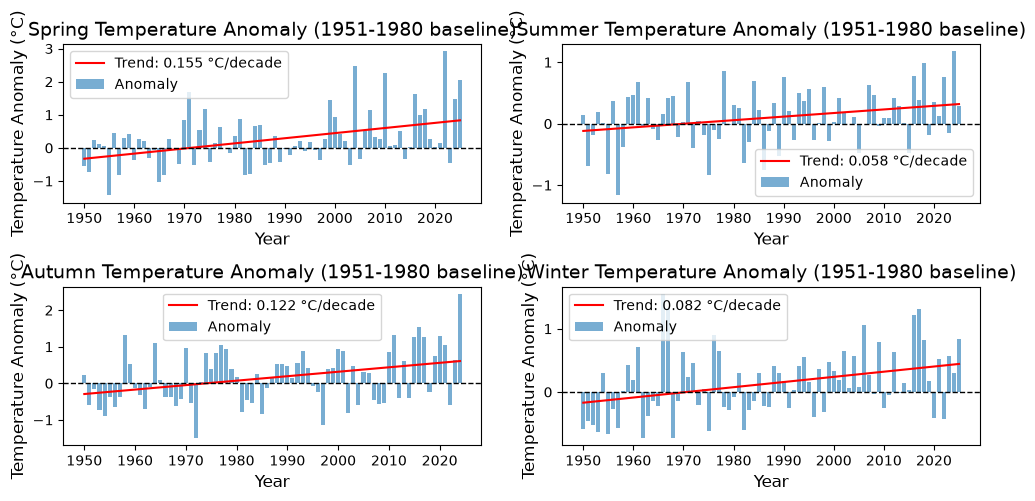

In [91]:
#%% Seasonal plot no color

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Prepare monthly data
df = era5_ts_monthly_mean.copy()
df['year'] = df.index.year
df['month'] = df.index.month

# Handle winter: assign December to previous year for winter season grouping
df['season_year'] = df['year']
df.loc[df['month'] == 12, 'season_year'] = df['year'] + 1  # Dec belongs to next year's winter

# Define seasons
season_months = {
    'Spring': [3,4,5],
    'Summer': [6,7,8],
    'Autumn': [9,10,11],
    'Winter': [12,1,2]
}

# Function to get seasonal mean temperature by season_year
def seasonal_means(df, season_name, months):
    if season_name != 'Winter':
        season_df = df[df['month'].isin(months)]
        seasonal_mean = season_df.groupby('year')['pred_temp'].mean()
    else:
        # For winter, use season_year grouping because Dec belongs to next year's winter
        season_df = df[df['month'].isin(months)]
        seasonal_mean = season_df.groupby('season_year')['pred_temp'].mean()
        seasonal_mean.index.name = 'year'
        seasonal_mean = seasonal_mean.sort_index()
    return seasonal_mean

# Compute seasonal mean series
spring_mean = seasonal_means(df, 'Spring', season_months['Spring'])
summer_mean = seasonal_means(df, 'Summer', season_months['Summer'])
autumn_mean = seasonal_means(df, 'Autumn', season_months['Autumn'])
winter_mean = seasonal_means(df, 'Winter', season_months['Winter'])

# Combine in a DataFrame
seasonal_df = pd.DataFrame({
    'Spring': spring_mean,
    'Summer': summer_mean,
    'Autumn': autumn_mean,
    'Winter': winter_mean
})

# Calculate baseline means for 1951-1980
baseline = seasonal_df.loc[(seasonal_df.index >= 1950) & (seasonal_df.index <= 1980)].mean()

# Calculate anomalies relative to baseline
seasonal_anomaly = seasonal_df - baseline

# Function to fit linear trend and return predictions and slope
def fit_trend(years, values):
    mask = ~np.isnan(values)
    x = years[mask].reshape(-1,1)
    y = values[mask]
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    slope = model.coef_[0]
    return y_pred, slope

# Plot side-by-side
fig, axs = plt.subplots(2, 2, figsize=(10, 5))
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']

for ax, season in zip(axs.flatten(), seasons):
    years = seasonal_anomaly.index.values
    values = seasonal_anomaly[season].values
    
    y_pred, slope = fit_trend(years, values)
    
    ax.bar(years, values, color='tab:blue', alpha=0.6, label='Anomaly')
    ax.plot(years[~np.isnan(values)], y_pred, color='red', label=f'Trend: {slope*10:.3f} °C/decade')
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{season} Temperature Anomaly (1951-1980 baseline)', fontsize=14)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Temperature Anomaly (°C)', fontsize=12)
    # ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

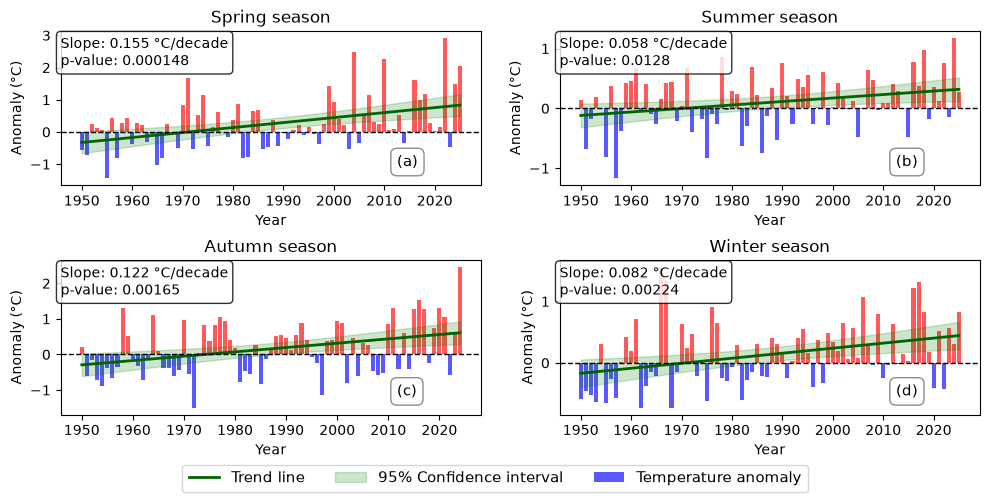

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


df = era5_ts_monthly_mean.copy()
df['year'] = df.index.year
df['month'] = df.index.month
df['season_year'] = df['year']

df.loc[df['month'] == 12, 'season_year'] = df['year'] + 1

# Define seasons
season_months = {
    'Spring': [3,4,5],
    'Summer': [6,7,8],
    'Autumn': [9,10,11],
    'Winter': [12,1,2]
}

def seasonal_means(df, season_name, months):
    if season_name != 'Winter':
        season_df = df[df['month'].isin(months)]
        seasonal_mean = season_df.groupby('year')['pred_temp'].mean()
    else:
        season_df = df[df['month'].isin(months)]
        seasonal_mean = season_df.groupby('season_year')['pred_temp'].mean()
        seasonal_mean.index.name = 'year'
        seasonal_mean = seasonal_mean.sort_index()
    return seasonal_mean

# Get seasonal means
spring = seasonal_means(df, 'Spring', season_months['Spring'])
summer = seasonal_means(df, 'Summer', season_months['Summer'])
autumn = seasonal_means(df, 'Autumn', season_months['Autumn'])
winter = seasonal_means(df, 'Winter', season_months['Winter'])

seasonal_df = pd.DataFrame({
    'Spring': spring,
    'Summer': summer,
    'Autumn': autumn,
    'Winter': winter
})

baseline = seasonal_df.loc[(seasonal_df.index >= 1950) & (seasonal_df.index <= 1980)].mean()
seasonal_anomaly = seasonal_df - baseline

fig, axs = plt.subplots(2, 2, figsize=(10, 5))

seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
all_handles = []
all_labels = []
fig_labels = ['(a)', '(b)', '(c)', '(d)']

for i, (ax, season) in enumerate(zip(axs.flatten(), seasons)):
    
    # ax.set_title(f"{i+1}. {season} Season")
    ax.set_title(f"{season} season")

    y = seasonal_anomaly[season].dropna()
    x = y.index.values
    X = sm.add_constant(x)
    
    model = sm.OLS(y.values, X).fit()
    predictions = model.get_prediction(X)
    summary = predictions.summary_frame(alpha=0.05)

    y_fit = summary['mean']
    ci_lower = summary['mean_ci_lower']
    ci_upper = summary['mean_ci_upper']
    
    # Plot elements
    bars = ax.bar(
        x, y.values,
        color=['red' if val > 0 else 'blue' for val in y.values], alpha=0.65,
        label='Temperature anomaly'
    )

   # bars = ax.bar(x, y.values, alpha=0.6, color='tab:blue', label='Anomaly')
    trend_line, = ax.plot(x, y_fit, color='darkgreen', label='Trend line', linewidth=2)
    ci = ax.fill_between(x, ci_lower, ci_upper, color='green', alpha=0.2, label='95% Confidence interval')
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    slope = model.params[1]
    p_value = model.pvalues[1]
    
    # ax.set_title(f'{season} Anomaly (1951–1980)', fontsize=14)
    ax.set_xlabel('Year')
    ax.set_ylabel('Anomaly (°C)')
    
    ax.text(0.000, 0.97,
            f'Slope: {slope*10:.3f} °C/decade\np-value: {p_value:.3g}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            fontsize=10)
    # ax.grid(True, linestyle='--', alpha=0.5)
    
    ax.text(
        0.8, 0.2, fig_labels[i],
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.4", edgecolor='gray', facecolor='white', alpha=0.9)
    )
    
    if not all_handles:
        all_handles, all_labels = ax.get_legend_handles_labels()

fig.legend(all_handles, all_labels,
           loc='lower center',
           ncol=3,
           fontsize=11,
           frameon=True,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.subplots_adjust(bottom=0.16)  # Add space for legend
plt.show()

# fig.savefig('Til-seasons.jpg', dpi=300)